In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors


In [29]:
# Read n-body benchmark results
def read_nbody_data(file_name):
    data = pd.read_csv(file_name, delimiter=",", skiprows=0)
    
    # Calculate total GPU time
    data['total_gpu_time_ms'] = (data['H2D_time_ms'] + 
                                  data['kernel_time_ms'] + 
                                  data['D2H_time_ms'])
    
    # Sort by num_elements
    data = data.sort_values('num_elements')
    
    print(f"Loaded {len(data)} data points from {file_name}")
    print(f"Particle counts: {sorted(data['num_elements'].unique())}")
    
    return data


In [30]:
# Load both datasets
original_data = read_nbody_data("nbody_benchmark_results.txt")
optimized_data = read_nbody_data("nbody_optimized_benchmark_results.txt")


Loaded 10 data points from nbody_benchmark_results.txt
Particle counts: [64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
Loaded 10 data points from nbody_optimized_benchmark_results.txt
Particle counts: [64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]


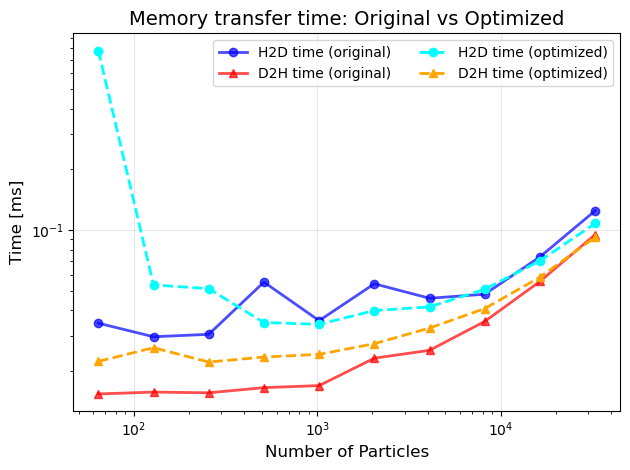

In [31]:
# Original version
plt.plot(original_data['num_elements'], original_data['H2D_time_ms'], 
         'o-', label='H2D time (original)', linewidth=2, markersize=6, color='blue', alpha=0.7)
plt.plot(original_data['num_elements'], original_data['D2H_time_ms'], 
         '^-', label='D2H time (original)', linewidth=2, markersize=6, color='red', alpha=0.7)

# Optimized version
plt.plot(optimized_data['num_elements'], optimized_data['H2D_time_ms'], 
         'o--', label='H2D time (optimized)', linewidth=2, markersize=6, color='cyan')
plt.plot(optimized_data['num_elements'], optimized_data['D2H_time_ms'], 
         '^--', label='D2H time (optimized)', linewidth=2, markersize=6, color='orange')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Particles', fontsize=12)
plt.ylabel('Time [ms]', fontsize=12)
plt.title('Memory transfer time: Original vs Optimized', fontsize=14)
plt.legend(fontsize=10, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nbody_performance_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()


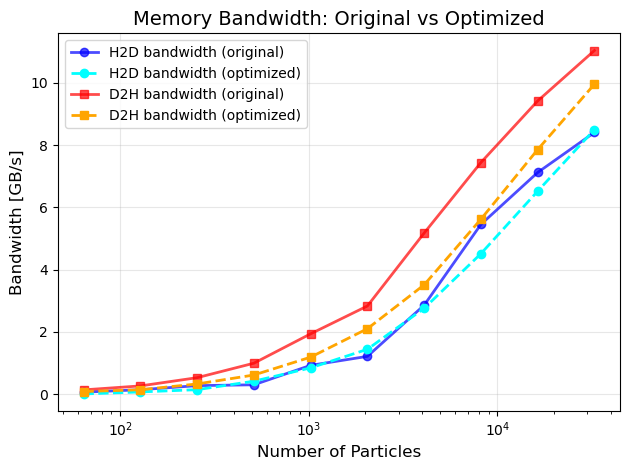

In [32]:

# H2D bandwidth
plt.plot(original_data['num_elements'], original_data['H2D_bandwidth_GBs'], 
         'o-', label='H2D bandwidth (original)', linewidth=2, markersize=6, color='blue', alpha=0.7)
plt.plot(optimized_data['num_elements'], optimized_data['H2D_bandwidth_GBs'], 
         'o--', label='H2D bandwidth (optimized)', linewidth=2, markersize=6, color='cyan')

# D2H bandwidth
plt.plot(original_data['num_elements'], original_data['D2H_bandwidth_GBs'], 
         's-', label='D2H bandwidth (original)', linewidth=2, markersize=6, color='red', alpha=0.7)
plt.plot(optimized_data['num_elements'], optimized_data['D2H_bandwidth_GBs'], 
         's--', label='D2H bandwidth (optimized)', linewidth=2, markersize=6, color='orange')

plt.xscale('log')
plt.xlabel('Number of Particles', fontsize=12)
plt.ylabel('Bandwidth [GB/s]', fontsize=12)
plt.title('Memory Bandwidth: Original vs Optimized', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nbody_bandwidth_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()


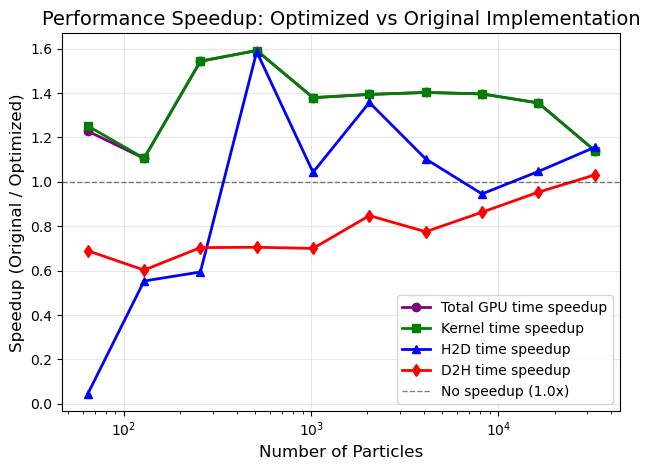

Max total GPU time speedup: 1.59x
Max kernel time speedup: 1.59x
Max H2D time speedup: 1.59x
Max D2H time speedup: 1.03x


In [33]:
# Plot 3: Speedup/Performance increase
# Merge dataframes on num_elements to calculate speedup
merged = pd.merge(original_data[['num_elements', 'H2D_time_ms', 'kernel_time_ms', 
                                  'D2H_time_ms', 'total_gpu_time_ms']], 
                  optimized_data[['num_elements', 'H2D_time_ms', 'kernel_time_ms', 
                                  'D2H_time_ms', 'total_gpu_time_ms']], 
                  on='num_elements', suffixes=('_orig', '_opt'))

# Calculate speedups
speedup_total = merged['total_gpu_time_ms_orig'] / merged['total_gpu_time_ms_opt']
speedup_kernel = merged['kernel_time_ms_orig'] / merged['kernel_time_ms_opt']
speedup_h2d = merged['H2D_time_ms_orig'] / merged['H2D_time_ms_opt']
speedup_d2h = merged['D2H_time_ms_orig'] / merged['D2H_time_ms_opt']

plt.plot(merged['num_elements'], speedup_total, 
         'o-', label='Total GPU time speedup', linewidth=2, markersize=6, color='purple')
plt.plot(merged['num_elements'], speedup_kernel, 
         's-', label='Kernel time speedup', linewidth=2, markersize=6, color='green')
plt.plot(merged['num_elements'], speedup_h2d, 
         '^-', label='H2D time speedup', linewidth=2, markersize=6, color='blue')
plt.plot(merged['num_elements'], speedup_d2h, 
         'd-', label='D2H time speedup', linewidth=2, markersize=6, color='red')

# Add horizontal line at speedup = 1.0
plt.axhline(y=1.0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='No speedup (1.0x)')

plt.xscale('log')
plt.xlabel('Number of Particles', fontsize=12)
plt.ylabel('Speedup (Original / Optimized)', fontsize=12)
plt.title('Performance Speedup: Optimized vs Original Implementation', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nbody_speedup.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f'Max total GPU time speedup: {speedup_total.max():.2f}x')
print(f'Max kernel time speedup: {speedup_kernel.max():.2f}x')
print(f'Max H2D time speedup: {speedup_h2d.max():.2f}x')
print(f'Max D2H time speedup: {speedup_d2h.max():.2f}x')


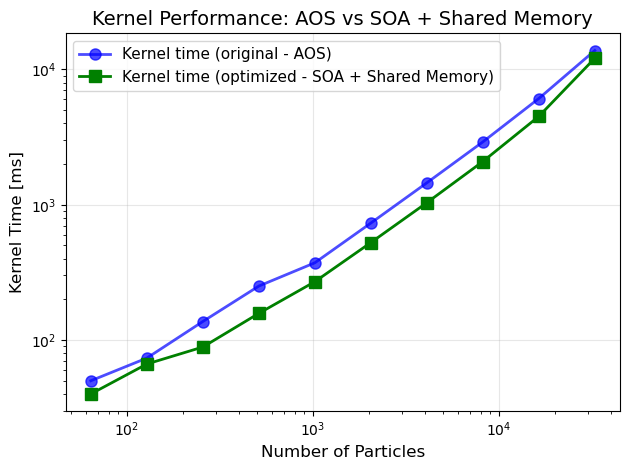

In [34]:
plt.plot(original_data['num_elements'], original_data['kernel_time_ms'], 
         'o-', label='Kernel time (original - AOS)', linewidth=2, markersize=8, color='blue', alpha=0.7)
plt.plot(optimized_data['num_elements'], optimized_data['kernel_time_ms'], 
         's-', label='Kernel time (optimized - SOA + Shared Memory)', linewidth=2, markersize=8, color='green')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Particles', fontsize=12)
plt.ylabel('Kernel Time [ms]', fontsize=12)
plt.title('Kernel Performance: AOS vs SOA + Shared Memory', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nbody_kernel_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [35]:
# Summary table
print("\n=== Performance Summary ===")
print(f"\n{'Particles':<12} {'Original Kernel [ms]':<20} {'Optimized Kernel [ms]':<22} {'Speedup':<10} {'Improvement':<12}")
print("-" * 80)
for idx, row in merged.iterrows():
    speedup = row['kernel_time_ms_orig'] / row['kernel_time_ms_opt']
    improvement = (1 - row['kernel_time_ms_opt'] / row['kernel_time_ms_orig']) * 100
    print(f"{int(row['num_elements']):<12} {row['kernel_time_ms_orig']:<20.2f} {row['kernel_time_ms_opt']:<22.2f} {speedup:<10.2f}x {improvement:<12.1f}%")



=== Performance Summary ===

Particles    Original Kernel [ms] Optimized Kernel [ms]  Speedup    Improvement 
--------------------------------------------------------------------------------
64           49.97                39.92                  1.25      x 20.1        %
128          73.50                66.45                  1.11      x 9.6         %
256          136.97               88.74                  1.54      x 35.2        %
512          250.44               157.37                 1.59      x 37.2        %
1024         372.10               269.81                 1.38      x 27.5        %
2048         731.34               524.77                 1.39      x 28.2        %
4096         1450.73              1034.41                1.40      x 28.7        %
8192         2910.90              2085.21                1.40      x 28.4        %
16384        6095.34              4497.29                1.36      x 26.2        %
32768        13796.18             12092.10               1.14

In [36]:
# Load loop unrolled (factor 4) dataset
loop4_data = read_nbody_data("nbody_optimized_benchmark_loop4_results.txt")


Loaded 10 data points from nbody_optimized_benchmark_loop4_results.txt
Particle counts: [64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]


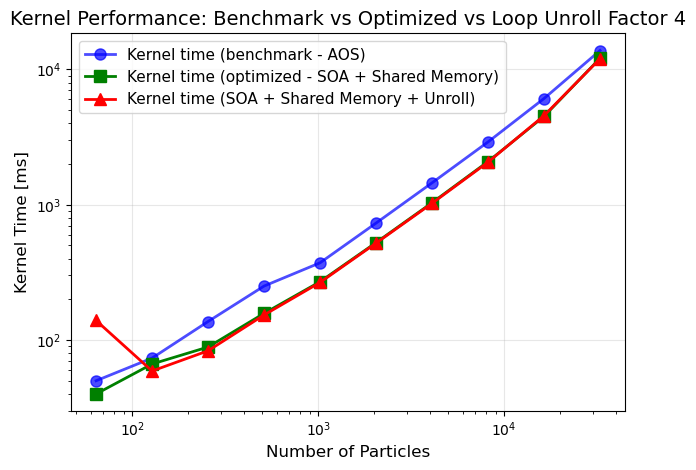

In [43]:
plt.plot(original_data['num_elements'], original_data['kernel_time_ms'], 
         'o-', label='Kernel time (benchmark - AOS)', linewidth=2, markersize=8, color='blue', alpha=0.7)
plt.plot(optimized_data['num_elements'], optimized_data['kernel_time_ms'], 
         's-', label='Kernel time (optimized - SOA + Shared Memory)', linewidth=2, markersize=8, color='green')
plt.plot(loop4_data['num_elements'], loop4_data['kernel_time_ms'], 
         '^-', label='Kernel time (SOA + Shared Memory + Unroll)', linewidth=2, markersize=8, color='red')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Particles', fontsize=12)
plt.ylabel('Kernel Time [ms]', fontsize=12)
plt.title('Kernel Performance: Benchmark vs Optimized vs Loop Unroll Factor 4', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nbody_kernel_comparison_all.pdf', dpi=300, bbox_inches='tight')
plt.show()


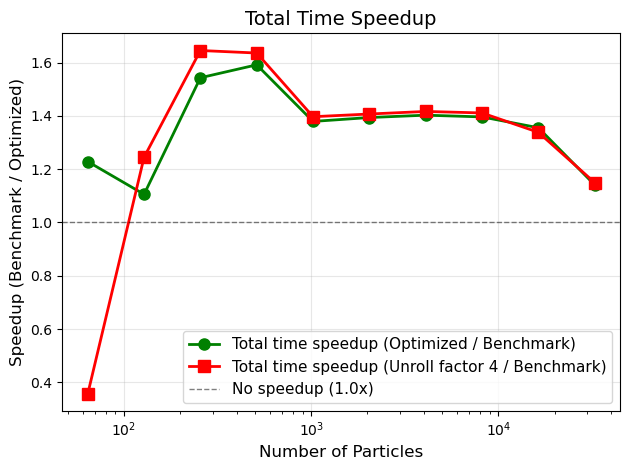

Max speedup (Optimized vs Benchmark): 1.59x
Max speedup (Loop4 vs Benchmark): 1.64x

Average speedup (Optimized vs Benchmark): 1.35x
Average speedup (Loop4 vs Benchmark): 1.30x


In [45]:
# Plot 2: Total time (kernel + data transfer) speedup over benchmark
# Merge all three datasets
merged_all = pd.merge(original_data[['num_elements', 'total_gpu_time_ms']], 
                      optimized_data[['num_elements', 'total_gpu_time_ms']], 
                      on='num_elements', suffixes=('_bench', '_opt'))
merged_all = pd.merge(merged_all, 
                      loop4_data[['num_elements', 'total_gpu_time_ms']], 
                      on='num_elements')
merged_all = merged_all.rename(columns={'total_gpu_time_ms': 'total_gpu_time_ms_loop4'})

# Calculate speedups over benchmark
speedup_opt_vs_bench = merged_all['total_gpu_time_ms_bench'] / merged_all['total_gpu_time_ms_opt']
speedup_loop4_vs_bench = merged_all['total_gpu_time_ms_bench'] / merged_all['total_gpu_time_ms_loop4']

plt.plot(merged_all['num_elements'], speedup_opt_vs_bench, 
         'o-', label='Total time speedup (Optimized / Benchmark)', linewidth=2, markersize=8, color='green')
plt.plot(merged_all['num_elements'], speedup_loop4_vs_bench, 
         's-', label='Total time speedup (Unroll factor 4 / Benchmark)', linewidth=2, markersize=8, color='red')

# Add horizontal line at speedup = 1.0
plt.axhline(y=1.0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='No speedup (1.0x)')

plt.xscale('log')
plt.xlabel('Number of Particles', fontsize=12)
plt.ylabel('Speedup (Benchmark / Optimized)', fontsize=12)
plt.title('Total Time Speedup', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nbody_total_time_speedup.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f'Max speedup (Optimized vs Benchmark): {speedup_opt_vs_bench.max():.2f}x')
print(f'Max speedup (Loop4 vs Benchmark): {speedup_loop4_vs_bench.max():.2f}x')
print(f'\nAverage speedup (Optimized vs Benchmark): {speedup_opt_vs_bench.mean():.2f}x')
print(f'Average speedup (Loop4 vs Benchmark): {speedup_loop4_vs_bench.mean():.2f}x')
